In [66]:
import DataMaker
import DataHolder
import buildmodel

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import time

In [67]:
ssplist = ["126","245","370","585"]
ssplist = ["245","370","585"]

In [68]:
# ssplist = ["245"]#,"370","585"]

# set user parameters

latsel = 40
lonsel = 250
# historical_era = [1960,2000]
experiment_era = [1950,2100]
baselineera = [1900,1950]
# tpercentile = 95
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

inputlength = 10
outputavgtime = 5

# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

In [69]:
imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
}

ntrain = 25
nval = 13
test = np.arange(38,50)


#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)


data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


In [70]:
seed = 42

np.random.seed(seed)

trainval = np.random.choice(ntrain+nval,ntrain+nval,replace=False)

trainvaltest = [trainval[:ntrain],trainval[ntrain:ntrain+nval],test]

alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

baseline for gmt is 60 90
experiment era in the historical is 50 119
baseline for temp records is 0 50
indices of future period are 104 -4
working on 245
working on 370
working on 585


In [71]:
np.mean(alltrain[-1])

0.3204109589041096

In [166]:
latindsel = np.argmin(np.abs((AllData.output_lat-latsel)))
lonindsel = np.argmin(np.abs((AllData.output_lon-lonsel)))

exprange = [experiment_era[0]-timerange[0],experiment_era[1]-timerange[0]]
baseline_era = [timerange[0]-timerange[0],experiment_era[0]-timerange[0]]

def find_records(temps,baseline):
    # Compare each value to the maximum of all previous values
    records = np.zeros(len(temps), dtype=bool)
    # records[0] = True  # First value is always a "record"
    current_max = np.copy(baseline)
    
    for i, temp in enumerate(temps):
        if temp > current_max:
            records[i] = 1
            current_max = temp

    return records

recordtemps = np.zeros((len(AllData.alloutput),AllData.alloutput[0].shape[0],AllData.alloutput[0].shape[1]-inputlength-50))

for issp,ssp in enumerate(ssplist):

    histsel = AllData.alloutput[issp]
    histsel = histsel[:,:,latindsel,lonindsel]

    baseline = np.max(histsel[:,baseline_era[0]:baseline_era[1]+inputlength],axis=1)
    
    for iens in range(histsel.shape[0]):

        recordtemps[issp,iens,:] = find_records(histsel[iens,exprange[0]+inputlength:],baseline[iens])



In [172]:
np.mean(recordtemps)

0.05361702127659575

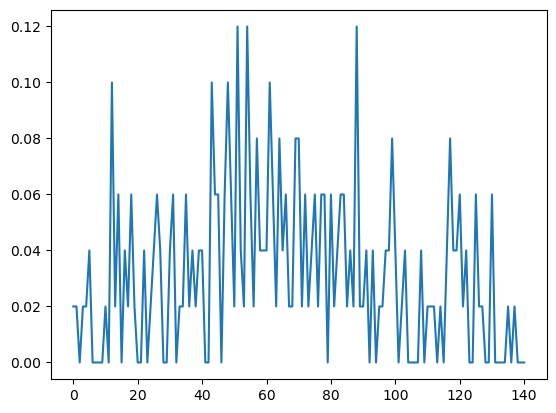

In [177]:
plt.plot(np.mean(recordtemps[0],axis=(0)))

In [87]:
# plt.subplot(1,1,1)
allpred = []

for iseed, seed in enumerate(seedlist[3:4]):

    torch.manual_seed(seed) 
    np.random.seed(seed)

    trainval = np.random.choice(ntrain+nval,ntrain+nval,replace=False)

    trainvaltest = [trainval[:ntrain],trainval[ntrain:ntrain+nval],test]

    alltrain, allval, alltest = AllData.trainvaltest_binaryclassifier(trainvaltest, historical_era,inputlength,outputavgtime, tpercentile, latsel, lonsel)

    inputtrain, inputtrainGMT, outputtrain = DataHolder.tensortime_onehot(alltrain,nclasses=2)
    inputval, inputvalGMT, outputval = DataHolder.tensortime_onehot(allval,nclasses=2)
    inputtest, inputtestGMT, outputtest = DataHolder.tensortime_onehot(alltest,nclasses=2)
    
    outputvalclass = np.argmax(outputval.numpy(),axis=1)
    outputtestclass = np.argmax(outputtest.numpy(),axis=1)

    #baseline of beating gmt, need to get gmt
    nullval,nulltest = AllData.calculate_nulls(trainvaltest)

    cnn = buildmodel.CNNclassifier(inputtrain, inputtrainGMT, outputtrain)
    fileout = "models/"+filefront+"avgtime"+str(outputavgtime)+"_allssps_per"+str(tpercentile)+"_lat"+str(latsel)+"_lon"+str(lonsel)+"_seed"+str(seed)+".pt"
    cnn.load_state_dict(torch.load(fileout, weights_only=True,map_location=torch.device('cpu')) )
    cnn.eval()

    with torch.no_grad():
        predval = cnn(inputval, inputvalGMT)
        predtest = cnn(inputtest, inputtestGMT)

    predvalclass = torch.argmax(predval, dim=1).numpy()
    allpred.append(predval.numpy())

    predtestclass = torch.argmax(predtest, dim=1).numpy()

    acc = np.mean(predvalclass == outputvalclass)
    acctest = np.mean(predtestclass == outputtestclass)
    gmtacc = np.mean(nullval == outputvalclass)

    gmttestacc = np.mean(nulltest == outputtestclass)

    print("Seed ", str(seed), " val accuracy: ", str(acc))
    print("Seed ", str(seed), " gmt val accuracy: ", str(gmtacc))

    print("Seed ", str(seed), " test accuracy: ", str(acctest))
    print("Seed ", str(seed), " gmt test accuracy: ", str(gmttestacc))

    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    # predseed = allpred[iseed]
    # predseed = np.argmax(predseed, axis=1)
    # predseed = np.reshape(predseed, (len(trainvaltest[1]), len(yearvec)))

    # predseedmean = np.mean(predseed, axis=0)
    # plt.plot(yearvec,predseedmean,label='Seed '+str(seed),linewidth=1.8,color='xkcd:indigo')

    # for i in range(len(trainvaltest[2])):
    #     plt.scatter(yearvec, allpred[iseed][i*len(yearvec):(i+1)*len(yearvec),1], color='xkcd:light purple', s=8)

    #     plt.title('ssp '+ssp + ' tpercentile' + str(tpercentile))

# plt.plot(yearvec,avgeffectofGMT_test,color='xkcd:blue',label='GMT only',linewidth=1.3)
# plt.plot(yearvec,avgeffectofGMTabs,color='xkcd:brown',label='GMT only',linewidth=1.3)

# gmtonlyacc = np.mean(avgeffectofGMTval == outputvalclass)
# print("GMT only val accuracy: ", str(gmtonlyacc))

# plt.xlim(2000,2040)


/Users/egor650/Documents/Experiments/predictability-emergence/DataHolder.py:644: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


Seed  10431957  val accuracy:  0.7582757799476065
Seed  10431957  gmt val accuracy:  0.7423195999047392
Seed  10431957  test accuracy:  0.7644478844169247
Seed  10431957  gmt test accuracy:  0.7636738906088751
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [88]:
allsummer = []

for i in range(5):
    truesummer = AllData.truesummer[i][25:38].flatten()
    allsummer.extend(truesummer)

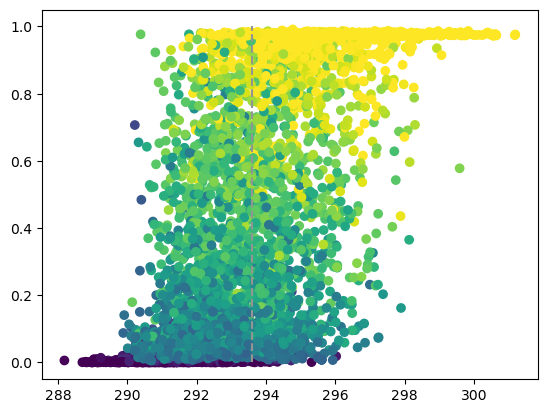

In [89]:
plt.scatter(allsummer,allpred[0][:,1],c=inputvalGMT.numpy(),vmin=0,vmax=1.5)
plt.vlines(np.mean(AllData.onesigmas),0,1,color='xkcd:grey',linestyle='dashed')

In [90]:
AllData.onesigmas.shape

(50,)

In [91]:
AllData.truesummer[2].shape

(50, 67)

In [92]:
allpred[0][:,1].shape

(4199,)

In [93]:
confusion_mat = np.empty((2,2))
confusion_mat_gmt = np.empty((2,2))

for i in range(2):
    for j in range(2):

        confusion_mat[i,j] = np.mean(1*((predvalclass==i) & (outputvalclass==j)))
        confusion_mat_gmt[i,j] = np.mean(1*((nullval==i) & (outputvalclass==j)))

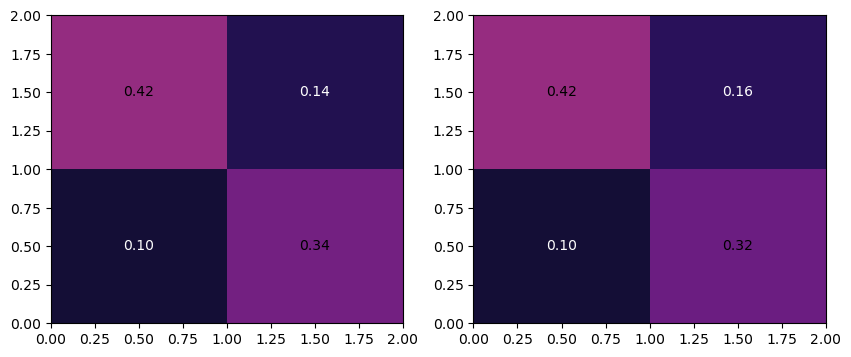

In [94]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
im1 = plt.pcolormesh(np.flipud(confusion_mat),vmin=0,vmax=1,cmap='magma')
nrows, ncols = confusion_mat.shape
for i in range(nrows):
    for j in range(ncols):
        val = confusion_mat[i, j]
        if abs(val - round(val)) < 1e-8:
            s = str(int(round(val)))
        else:
            s = "{:.2f}".format(val)
        x = j + 0.5
        y = nrows - i - 0.5
        text_color = 'white' if val < (confusion_mat.max() / 2.0) else 'black'
        plt.text(x, y, s, ha='center', va='center', color=text_color)


plt.subplot(1,2,2)
plt.pcolormesh(np.flipud(confusion_mat_gmt),vmin=0,vmax=1,cmap='magma')
nrows2, ncols2 = confusion_mat_gmt.shape
for i in range(nrows2):
    for j in range(ncols2):
        val = confusion_mat_gmt[i, j]
        if abs(val - round(val)) < 1e-8:
            s = str(int(round(val)))
        else:
            s = "{:.2f}".format(val)
        x = j + 0.5
        y = nrows2 - i - 0.5
        text_color = 'white' if val < (confusion_mat_gmt.max() / 2.0) else 'black'
        plt.text(x, y, s, ha='center', va='center', color=text_color)

In [97]:
f1score = 2*confusion_mat[1,1]/(2*confusion_mat[1,1] + confusion_mat[1,0] + confusion_mat[0,1])
print(f1score)

f1score_gmt = 2*confusion_mat_gmt[1,1]/(2*confusion_mat_gmt[1,1] + confusion_mat_gmt[1,0] + confusion_mat_gmt[0,1])
print(f1score_gmt)

0.7360208062418725
0.7126925119490175
